In [4]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
USERNAME = "neo4j"
PASSWORD = "AaRrRmM6645@"

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

driver.verify_connectivity()

print("Connected successfully!")

Connected successfully!


## Descriptive stats — the shape of the graph

In [3]:
with driver.session() as s:
    info = s.run("CALL db.info()").single()
    print(info)

<Record id='637A1ACF2C82D444D49585349B3645B0295C7CD8783ABBAD3287A7442599042C' name='neo4j' creationDate='2026-05-20T12:44:39.032Z'>


In [8]:
def cypher(query, **params):
    with driver.session() as s:
        return pd.DataFrame([r.data() for r in s.run(query, **params)])

cypher("""
    MATCH (n)
    RETURN labels(n)[0] AS label, count(*) AS count
    ORDER BY count DESC
""")

,label,count
0,Company,18244
1,Case,10917
2,Section,21
3,LegalBasis,12


In [9]:
cypher("""
    MATCH ()-[r]->()
    RETURN type(r) AS relationship, count(*) AS count
    ORDER BY count DESC
""")

,relationship,count
0,INVOLVES_COMPANY,29222
1,HAS_LEGAL_BASIS,11192
2,HAS_SECTION,10919


In [10]:
cypher("""
    MATCH (c:Case)-[:INVOLVES_COMPANY]->(co:Company)
    RETURN c.caseNumber AS caseNumber,
           c.caseTitle  AS caseTitle,
           collect(co.name) AS companies
    LIMIT 5
""")

,caseNumber,caseTitle,companies
0,2027,DEUTSCHE BANK / SAP / JV,"[DEUTSCHE BANK, SAP]"
1,2028,ABB / BILFINGER / MVV ENERGIE / JV,"[ABB, BILFINGER, MVV ENERGIE]"
2,422,UNILEVER FRANCE / ORTIZ MIKO (II),"[UNILEVER FRANCE, ORTIZ MIKO (II)]"
3,2029,TATE & LYLE / AMYLUM,"[TATE & LYLE, AMYLUM]"
4,420,KPR / CGP,"[KPR, CGP]"


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [13]:
# Merger vs antitrust split
cypher("""
    MATCH (c:Case)
    RETURN c.caseInstrument AS instrument, count(*) AS cases
    ORDER BY cases DESC
""")

,instrument,cases
0,Merger,10216
1,Antitrust & Cartels,701


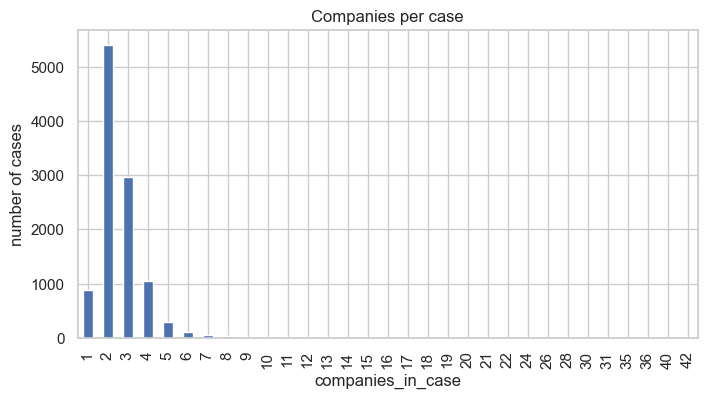

In [14]:
# Distribution: how many companies per case?
df = cypher("""
    MATCH (c:Case)
    OPTIONAL MATCH (c)-[:INVOLVES_COMPANY]->(co:Company)
    WITH c, count(co) AS n
    RETURN n AS companies_in_case, count(c) AS cases
    ORDER BY companies_in_case
""")
df.plot(x="companies_in_case", y="cases", kind="bar", legend=False, figsize=(8,4))
plt.title("Companies per case"); plt.ylabel("number of cases"); plt.show()

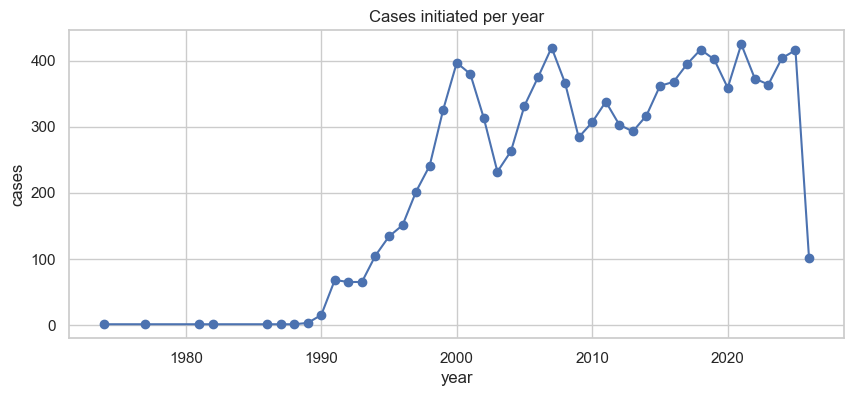

In [15]:
# Cases per year
df = cypher("""
    MATCH (c:Case)
    WHERE c.caseInitiationDate IS NOT NULL
    RETURN c.caseInitiationDate.year AS year, count(*) AS cases
    ORDER BY year
""")
df.plot(x="year", y="cases", kind="line", marker="o", figsize=(10,4), legend=False)
plt.title("Cases initiated per year"); plt.ylabel("cases"); plt.show()

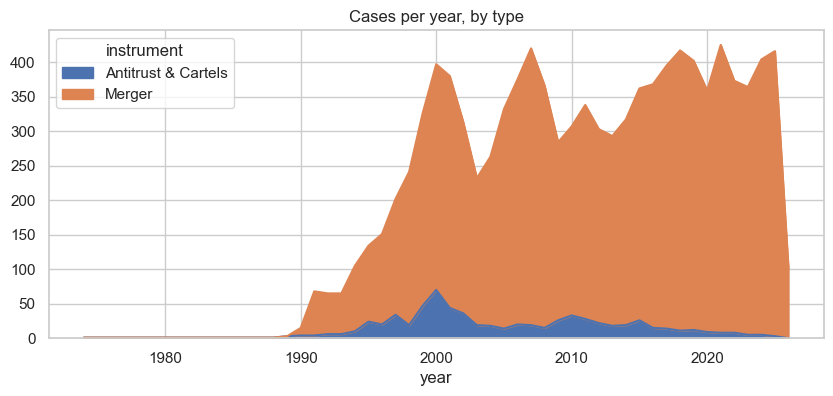

In [16]:
# Mergers vs antitrust over time
df = cypher("""
    MATCH (c:Case)
    WHERE c.caseInitiationDate IS NOT NULL
    RETURN c.caseInitiationDate.year AS year,
           c.caseInstrument AS instrument,
           count(*) AS cases
    ORDER BY year, instrument
""")
df.pivot(index="year", columns="instrument", values="cases").fillna(0).plot(
    kind="area", stacked=True, figsize=(10,4))
plt.title("Cases per year, by type"); plt.show()

In [17]:
# Average case duration (decision date − initiation date), in days
cypher("""
    MATCH (c:Case)
    WHERE c.caseInitiationDate IS NOT NULL AND c.caseLastDecisionDate IS NOT NULL
    WITH c, duration.between(c.caseInitiationDate, c.caseLastDecisionDate).days AS days
    RETURN c.caseInstrument AS instrument,
           count(*) AS cases,
           round(avg(days)) AS avg_days,
           min(days) AS min_days,
           max(days) AS max_days
""")

,instrument,cases,avg_days,min_days,max_days
0,Merger,9959,14.0,0,30
1,Antitrust & Cartels,495,15.0,0,30


## Network analysis — companies, hubs, co-occurrence

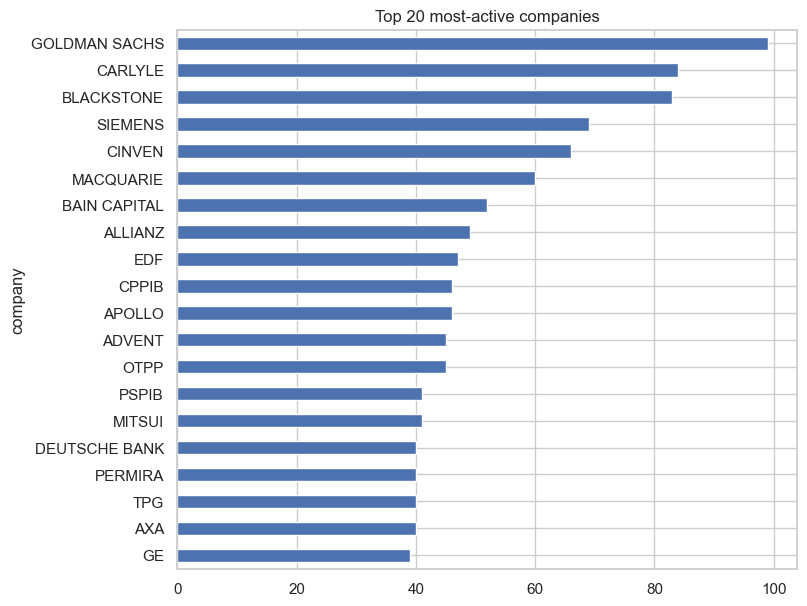

In [18]:
# Top 20 most-active companies
df = cypher("""
    MATCH (co:Company)<-[:INVOLVES_COMPANY]-(c:Case)
    WHERE co.name <> 'null'
    RETURN co.name AS company, count(c) AS cases
    ORDER BY cases DESC
    LIMIT 20
""")
df.sort_values("cases").plot(x="company", y="cases", kind="barh", figsize=(8,7), legend=False)
plt.title("Top 20 most-active companies"); plt.show()

In [19]:
# Co-occurrence: which company pairs appear together most often?
cypher("""
    MATCH (co1:Company)<-[:INVOLVES_COMPANY]-(c:Case)-[:INVOLVES_COMPANY]->(co2:Company)
    WHERE co1.name < co2.name
      AND co1.name <> 'null' AND co2.name <> 'null'
    RETURN co1.name AS company_a, co2.name AS company_b, count(c) AS shared_cases
    ORDER BY shared_cases DESC
    LIMIT 20
""")

,company_a,company_b,shared_cases
0,PSPIB,SEGRO,21
1,PSPIB,SELP,11
2,SEGRO,SELP,11
3,GOLDMAN SACHS,TPG LUNDY,10
4,HPS,MDP,8
5,ENGIE,OMNES CAPITAL,7
6,ENGIE,PREDICA,6
7,CLEARLAKE,TA ASSOCIATES,5
8,INEOS,SINOPEC,5
9,Hitachi Ltd,Mitsubishi Electric Corporation,5


In [20]:
# Companies active across the most different industries
cypher("""
    MATCH (co:Company)<-[:INVOLVES_COMPANY]-(c:Case)-[:HAS_SECTION]->(s:Section)
    WHERE co.name <> 'null'
    RETURN co.name AS company,
           count(DISTINCT s) AS sectors_touched,
           count(c) AS total_cases
    ORDER BY sectors_touched DESC
    LIMIT 15
""")

,company,sectors_touched,total_cases
0,GOLDMAN SACHS,16,99
1,BLACKSTONE,15,83
2,OTPP,14,45
3,CINVEN,13,66
4,BRIDGEPOINT,13,37
5,TPG,13,40
6,CPPIB,13,46
7,3i,13,26
8,OMERS,12,23
9,CARLYLE,12,84


## Industry deep-dive

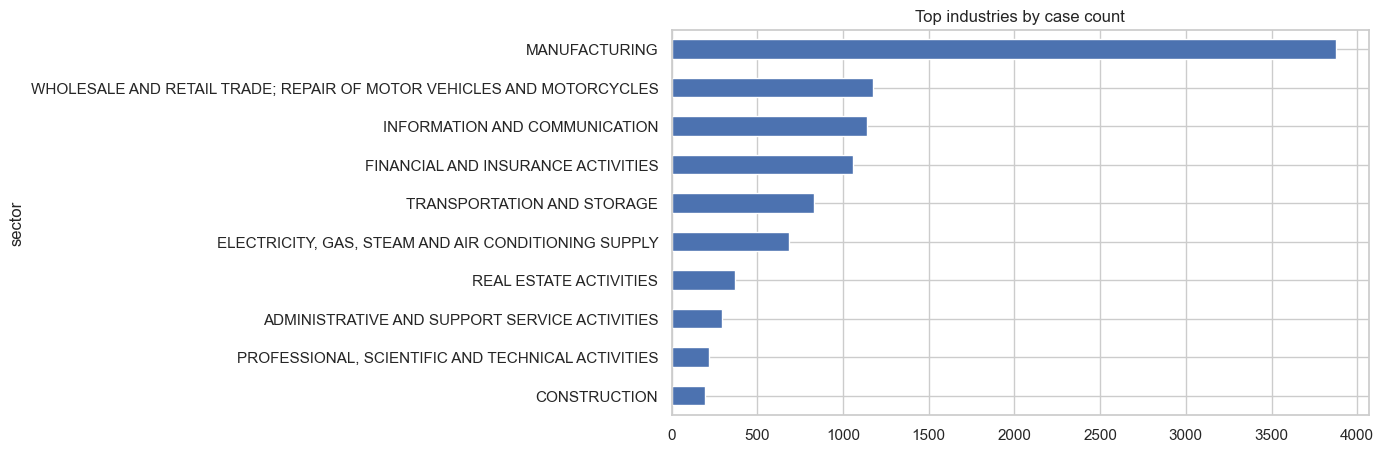

In [21]:
# Top sectors by case count
df = cypher("""
    MATCH (c:Case)-[:HAS_SECTION]->(s:Section)
    RETURN s.name AS sector, count(c) AS cases
    ORDER BY cases DESC
""")
df.head(10).sort_values("cases").plot(x="sector", y="cases", kind="barh", figsize=(9,5), legend=False)
plt.title("Top industries by case count"); plt.show()

In [22]:
# For one sector, which companies dominate?  (change the sector name)
cypher("""
    MATCH (s:Section {name: 'INFORMATION AND COMMUNICATION'})<-[:HAS_SECTION]-(c:Case)
          -[:INVOLVES_COMPANY]->(co:Company)
    WHERE co.name <> 'null'
    RETURN co.name AS company, count(c) AS cases_in_sector
    ORDER BY cases_in_sector DESC
    LIMIT 15
""")

,company,cases_in_sector
0,TA ASSOCIATES,23
1,TELEFONICA,20
2,BLACKSTONE,18
3,VISTA,17
4,BT,17
5,VODAFONE,15
6,BERTELSMANN,15
7,PERMIRA,13
8,GOLDMAN SACHS,13
9,ADVENT,12


In [23]:
# Antitrust hotspots — which sectors see most investigations?
cypher("""
    MATCH (c:Case {caseInstrument: 'Antitrust & Cartels'})-[:HAS_SECTION]->(s:Section)
    RETURN s.name AS sector, count(c) AS antitrust_cases
    ORDER BY antitrust_cases DESC
    LIMIT 10
""")

,sector,antitrust_cases
0,MANUFACTURING,266
1,TRANSPORTATION AND STORAGE,108
2,INFORMATION AND COMMUNICATION,100
3,WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VE...,50
4,FINANCIAL AND INSURANCE ACTIVITIES,47
5,"ELECTRICITY, GAS, STEAM AND AIR CONDITIONING S...",45
6,"ARTS, ENTERTAINMENT AND RECREATION",26
7,"WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND R...",11
8,null,9
9,"PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES",9


## legal patterns

In [24]:
# Top legal bases overall
cypher("""
    MATCH (c:Case)-[:HAS_LEGAL_BASIS]->(l:LegalBasis)
    RETURN l.name AS article, count(c) AS cases
    ORDER BY cases DESC
""")

,article,cases
0,Art. 105,10221
1,Art. 101,534
2,Art. 102,266
3,Art. 53,90
4,Art. 106,37
5,Art. 54,28
6,Art. 258,8
7,Art. 65,3
8,Art. 4,2
9,Art. 37,1


In [25]:
# Legal bases that appear together
cypher("""
    MATCH (l1:LegalBasis)<-[:HAS_LEGAL_BASIS]-(c:Case)-[:HAS_LEGAL_BASIS]->(l2:LegalBasis)
    WHERE l1.name < l2.name
    RETURN l1.name AS article_a, l2.name AS article_b, count(c) AS co_cited_cases
    ORDER BY co_cited_cases DESC
    LIMIT 10
""")

,article_a,article_b,co_cited_cases
0,Art. 101,Art. 102,117
1,Art. 101,Art. 53,90
2,Art. 102,Art. 54,28
3,Art. 102,Art. 106,23
4,Art. 101,Art. 106,14
5,Art. 53,Art. 54,2
6,Art. 102,Art. 53,2
7,Art. 101,Art. 105,2
8,Art. 101,Art. 54,2
9,Art. 102,Art. 4,2


In [26]:
# Legal basis vs case type — which articles get cited in mergers vs antitrust?
cypher("""
    MATCH (c:Case)-[:HAS_LEGAL_BASIS]->(l:LegalBasis)
    RETURN l.name AS article,
           c.caseInstrument AS instrument,
           count(c) AS cases
    ORDER BY cases DESC
""").pivot(index="article", columns="instrument", values="cases").fillna(0)

instrument,Antitrust & Cartels,Merger
article,,
Art. 101,534.0,0.0
Art. 102,266.0,0.0
Art. 105,5.0,10216.0
Art. 106,37.0,0.0
Art. 23,1.0,0.0
Art. 258,8.0,0.0
Art. 37,1.0,0.0
Art. 4,2.0,0.0
Art. 53,90.0,0.0
